In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from helpers.data_transforms import load_in_data

plt.style.use("../science.mplstyle")



/scratch/midway3/rmastand/muon_collider_env/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [7]:
with open("configs.yaml", "r") as f:
    configs = yaml.safe_load(f)



ALL_COLLECTIONS = configs["ALL_COLLECTIONS"]
PATH_TO_DATA_DIR = configs["PATH_TO_DATA_DIR"]
NUM_COND_INPUTS = configs["NUM_COND_INPUTS"]
FEATURE_ORDER = configs["FEATURE_ORDER"]


log_vars = []
BASIS = "rphi"
MODEL = "flow"
NUM_BINS = configs["NUM_BINS"]


PATH_TO_SAVE_SAMPLES = configs["PATH_TO_SAVE_SAMPLES"] + f"{MODEL}_{BASIS}/"


In [18]:
# load in data


NN = -1

all_data_dir, flow_samples_dir = {}, {}
bins_dict = {}
feature_labels_dict = {}

for col_name in ALL_COLLECTIONS:

    X, _ = load_in_data([col_name], BASIS, PATH_TO_DATA_DIR, 1, NUM_COND_INPUTS, FEATURE_ORDER)
    
    all_data_dir[col_name] = X[:NN]

    flow_samples_dir[col_name] = np.load(f"{PATH_TO_SAVE_SAMPLES}/{col_name}.npy", allow_pickle=True)[:NN]

    bins_dict[col_name] = {}

    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 





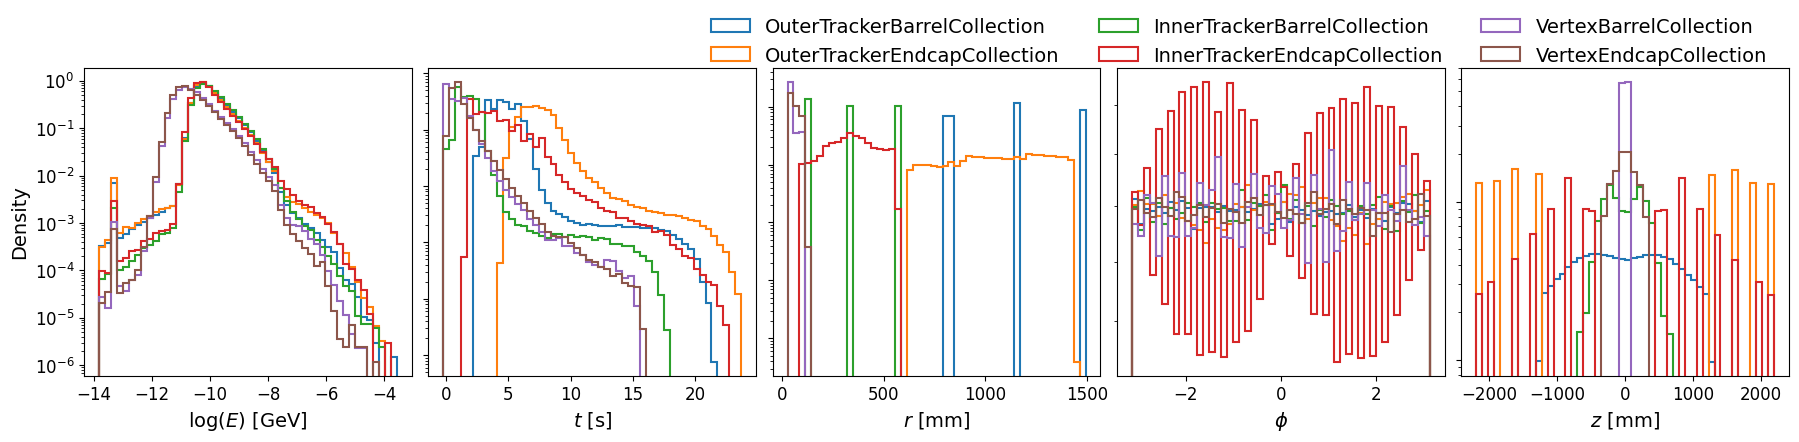

In [19]:
# Sim BIB

feature_labels = ["log($E$) [GeV]", "$t$ [s]", "$r$ [mm]", "$\\phi$", "$z$ [mm]"]
from matplotlib.ticker import NullFormatter

fig, ax = plt.subplots(
    1, 5,
    figsize=(22, 4),
    sharey=False
)

for i in range(5):

    # Common binning across collections
    vals = np.concatenate([
        all_data_dir[col_name][:, i]
        for col_name in ALL_COLLECTIONS
    ])
    bins = np.histogram_bin_edges(vals, bins=50)

    for col_name in ALL_COLLECTIONS:
        ax[i].hist(
            all_data_dir[col_name][:, i],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=col_name,
        )

    ax[i].set_xlabel(feature_labels[i], fontsize=14)

    ax[i].set_yscale("log")

    # Only left-most panel gets y label
    if i == 0:
        ax[i].set_ylabel("Density", fontsize=14)
    else:
        ax[i].yaxis.set_tick_params(labelleft=False)
        ax[i].yaxis.set_ticklabels([])  # explicitly clear tick labels
        ax[i].yaxis.set_major_formatter(NullFormatter())
        ax[i].yaxis.set_minor_formatter(NullFormatter())

    ax[i].tick_params(labelsize=12)
    

# Single legend above all panels
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.65, 1.05),
    ncol=3,
    frameon=False,
    fontsize=14,
)

# Reduce spacing between panels
plt.subplots_adjust(
    # left=0.06,
    # right=0.995,
    # bottom=0.18,
    # top=0.78,
    wspace=0.05,
)

plt.show()





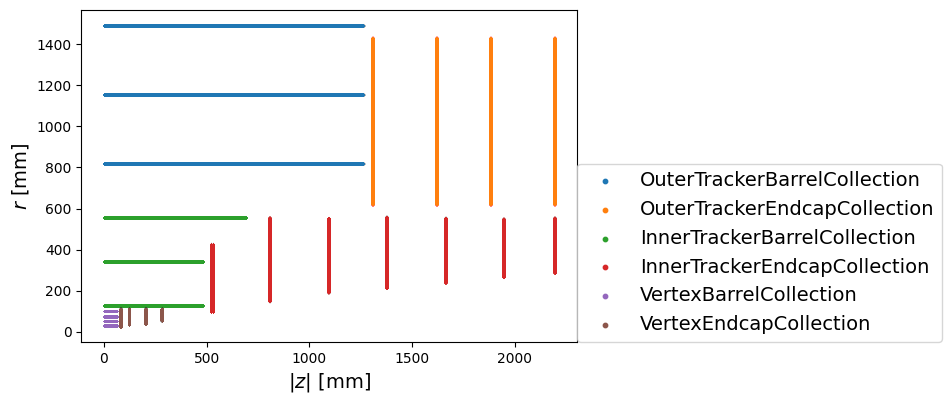

In [20]:

plt.figure()
for col_name in ALL_COLLECTIONS:
    plt.scatter(np.abs(all_data_dir[col_name][:1000000,4]), all_data_dir[col_name][:1000000,2], label = col_name, s = 0.00001)

plt.ylabel("$r$ [mm]", fontsize = 14)
plt.xlabel("$|z|$ [mm]", fontsize = 14)
plt.gca().set_aspect("equal", adjustable="box")

plt.legend(markerscale=1000, loc = (1,0), fontsize = 14)
plt.show()


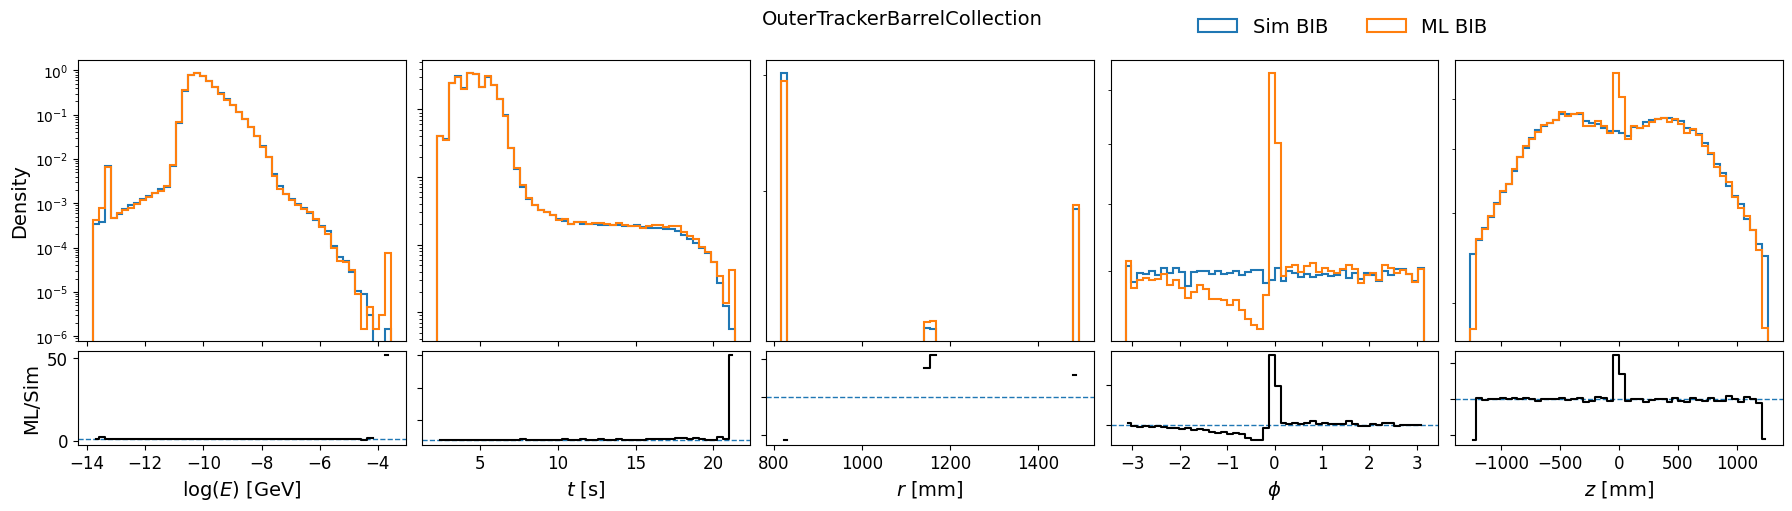

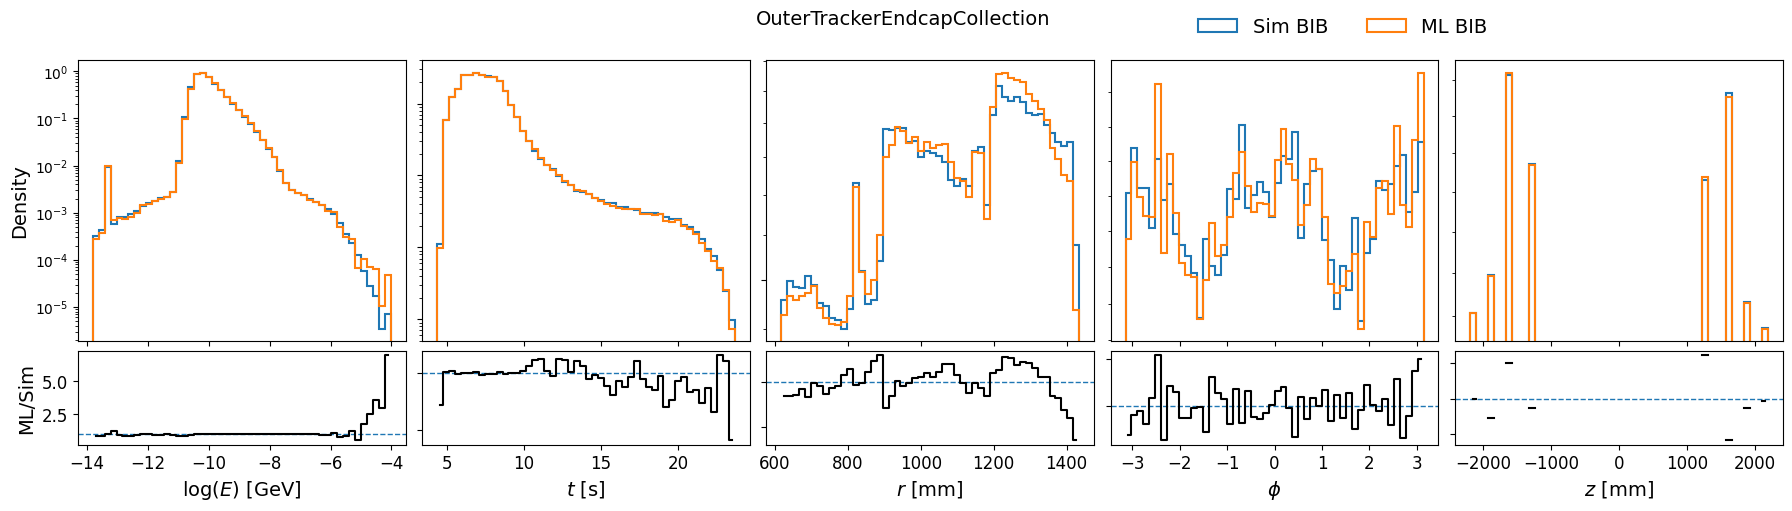

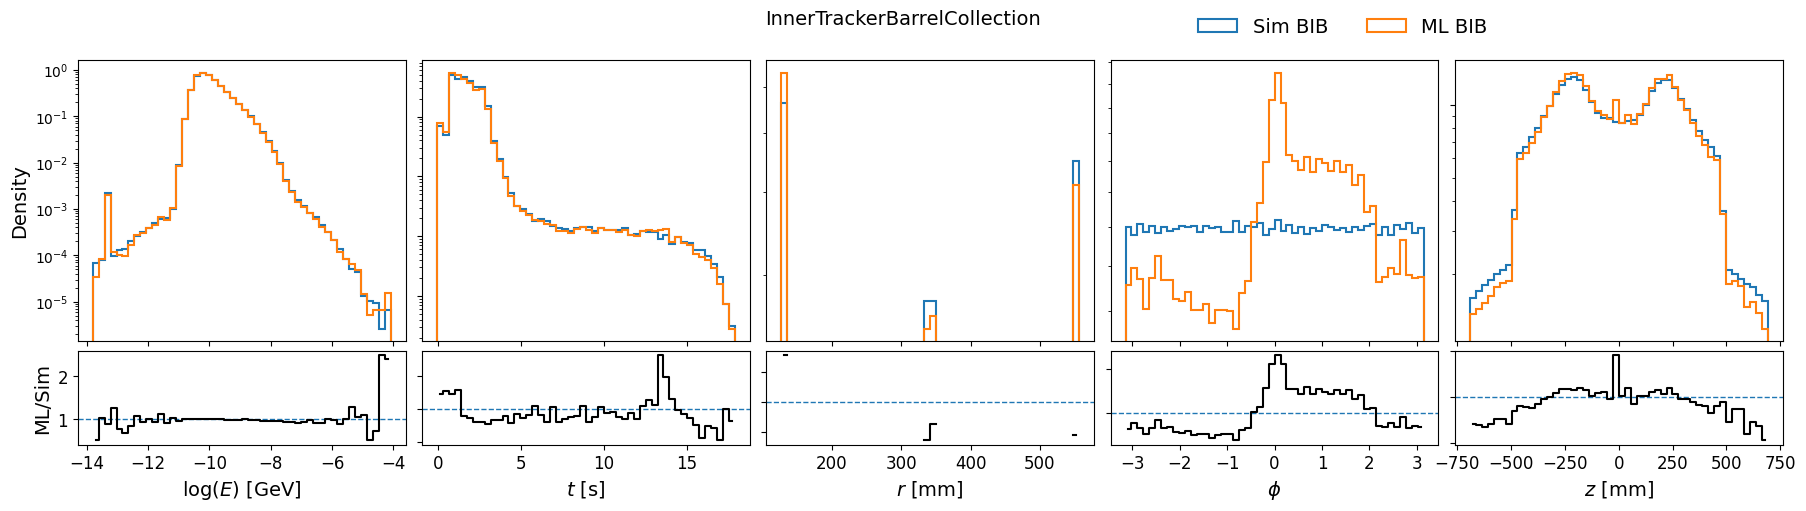

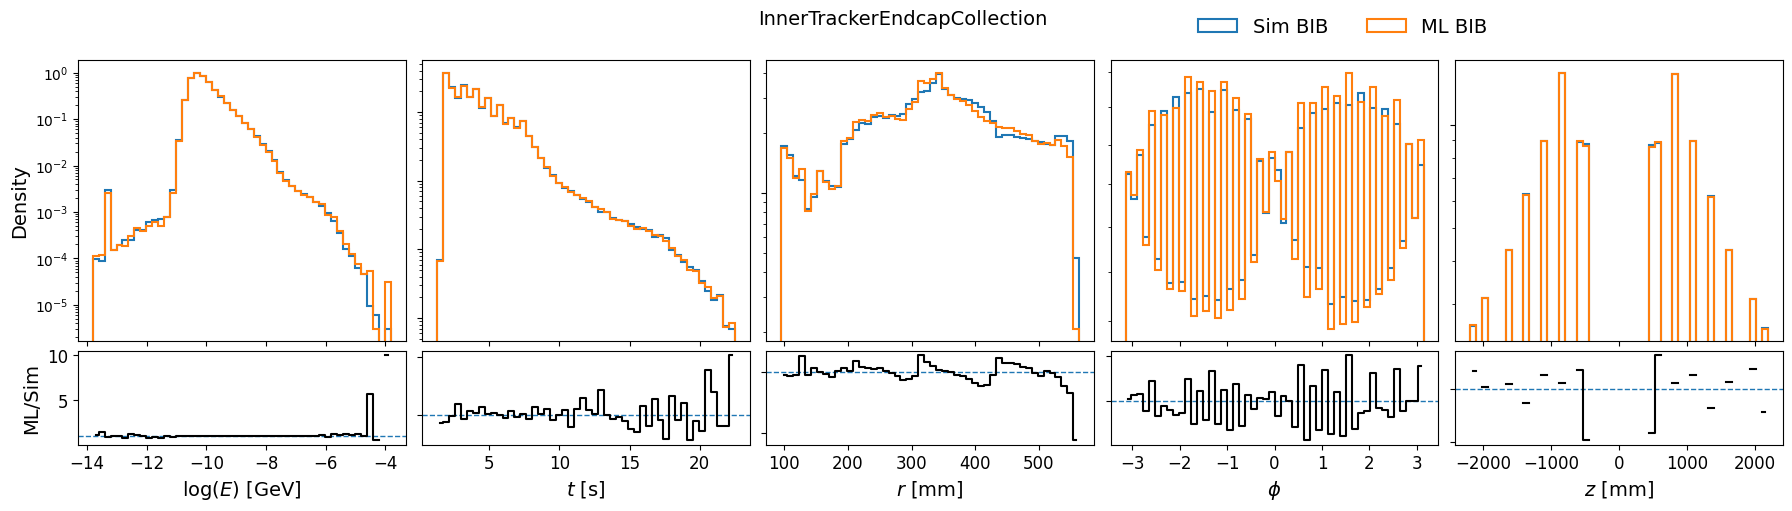

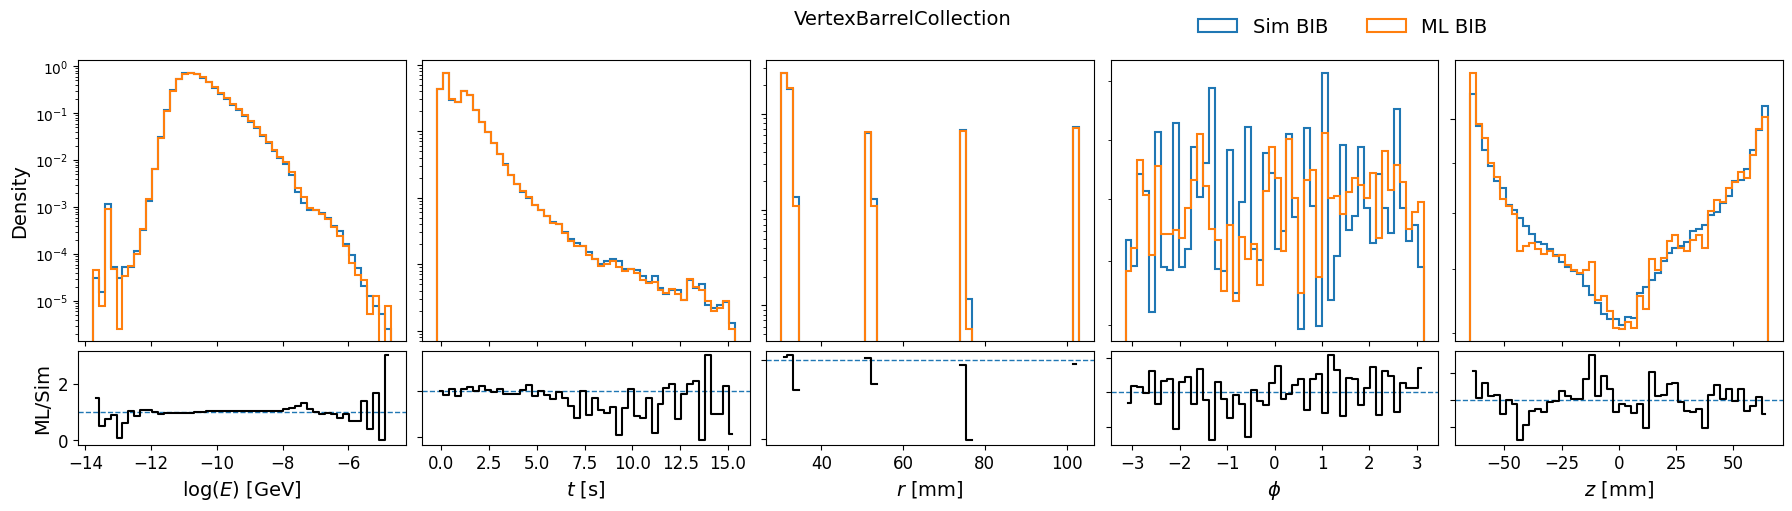

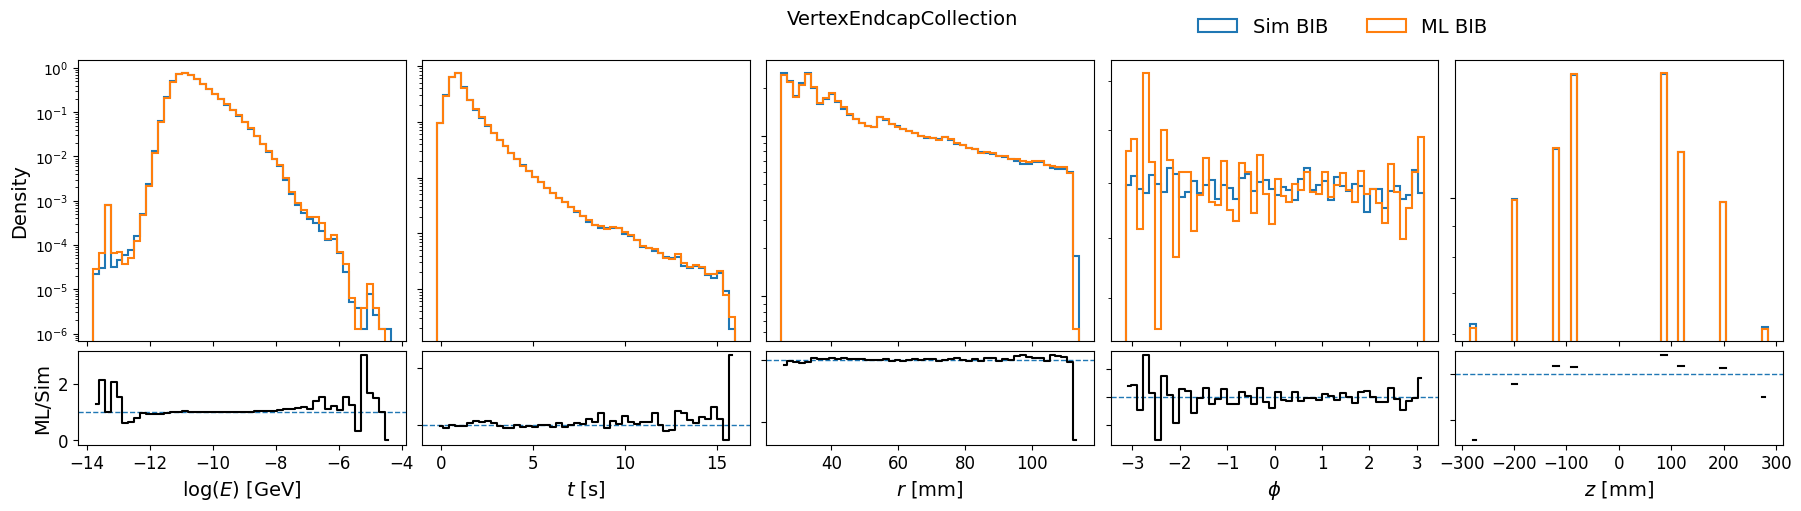

In [21]:
# ML BIB: per-collection data vs flow + ratio

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter


n_bins = 50
eps = 1e-12

for col_name in ALL_COLLECTIONS:

    fig, ax = plt.subplots(
        2, 5,
        figsize=(22, 5),
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    for i in range(5):

        data_vals = all_data_dir[col_name][:, i]
        flow_vals = flow_samples_dir[col_name][:, i]

        # Common binning for data + flow in this collection/feature
        vals = np.concatenate([data_vals, flow_vals])
        bins = np.histogram_bin_edges(vals, bins=n_bins)

        # Histogram values for ratio
        data_hist, _ = np.histogram(data_vals, bins=bins, density=True)
        flow_hist, _ = np.histogram(flow_vals, bins=bins, density=True)

        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        ratio = np.divide(
            flow_hist,
            data_hist,
            out=np.full_like(flow_hist, np.nan, dtype=float),
            where=data_hist > eps,
        )

        # -------------------------
        # Top: densities
        # -------------------------
        ax[0, i].hist(
            data_vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label="Sim BIB",
        )

        ax[0, i].hist(
            flow_vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label="ML BIB",
        )

        ax[0, i].set_yscale("log")

        if i == 0:
            ax[0, i].set_ylabel("Density", fontsize=14)
        else:
            ax[0, i].yaxis.set_tick_params(labelleft=False)
            ax[0, i].yaxis.set_ticklabels([])
            ax[0, i].yaxis.set_major_formatter(NullFormatter())
            ax[0, i].yaxis.set_minor_formatter(NullFormatter())

        ax[0, i].tick_params(labelsize=10)

        # -------------------------
        # Bottom: flow / data ratio
        # -------------------------
        ax[1, i].axhline(1.0, linestyle="--", linewidth=1)

        ax[1, i].step(
            bin_centers,
            ratio,
            where="mid",
            linewidth=1.5,
            color = "k"
        )

        ax[1, i].set_xlabel(feature_labels[i], fontsize=14)

        if i == 0:
            ax[1, i].set_ylabel("ML/Sim", fontsize=14)
        else:
            ax[1, i].yaxis.set_tick_params(labelleft=False)
            ax[1, i].yaxis.set_ticklabels([])

        ax[1, i].tick_params(labelsize=12)

    # Single legend above panels
    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.7, 1.0),
        ncol=2,
        frameon=False,
        fontsize=14,
    )

    fig.suptitle(col_name, fontsize=14)#, y=1.0)

    plt.subplots_adjust(
        wspace=0.05,
        #top=0.88,
    )

    plt.show()